In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

- 2013년이후 전국 아파트분양가격
- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [87]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지
# 다른 폰트를 기본으로 하려면
# file_path = 'data/font/적용할 폰트.ttf'
# fontproperties = FontProperties(fname=file_path, size=15)

from matplotlib.font_manager import FontProperties # 대문자 시작은 클래스
# font_path = 'C:/Users/mbc1/AppData/Local/Microsoft/Windows/Fonts/MaruBuri-SemiBold.ttf'
# font_Manager.addfont(font_path)
# font_prop = FontProperties(fname=font_path, size=15)
# font_name = font_prop.get_name()
# plt.rc('font', family='MaruBuri-SemiBold.ttf') # 윈도우즈
# plt.rc('font', size=20)
# plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [88]:
pd.read_csv?

In [89]:
df_first = pd.read_csv(r'C:/ai/downloads/sharedata/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [90]:
pd.options.display.max_columns = 22 # 최대 display 가능한 열수 변경

In [91]:
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
12,전북,6282,6281,5946,5966,6277,6306,6351,6319,6436,6719,6581,6583,6583,6583,6583,6542,6551,6556,6601,6750,6580


In [92]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [93]:
df_first.set_index('지역')

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,8038,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,8627,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,10397,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,8527,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


In [94]:
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

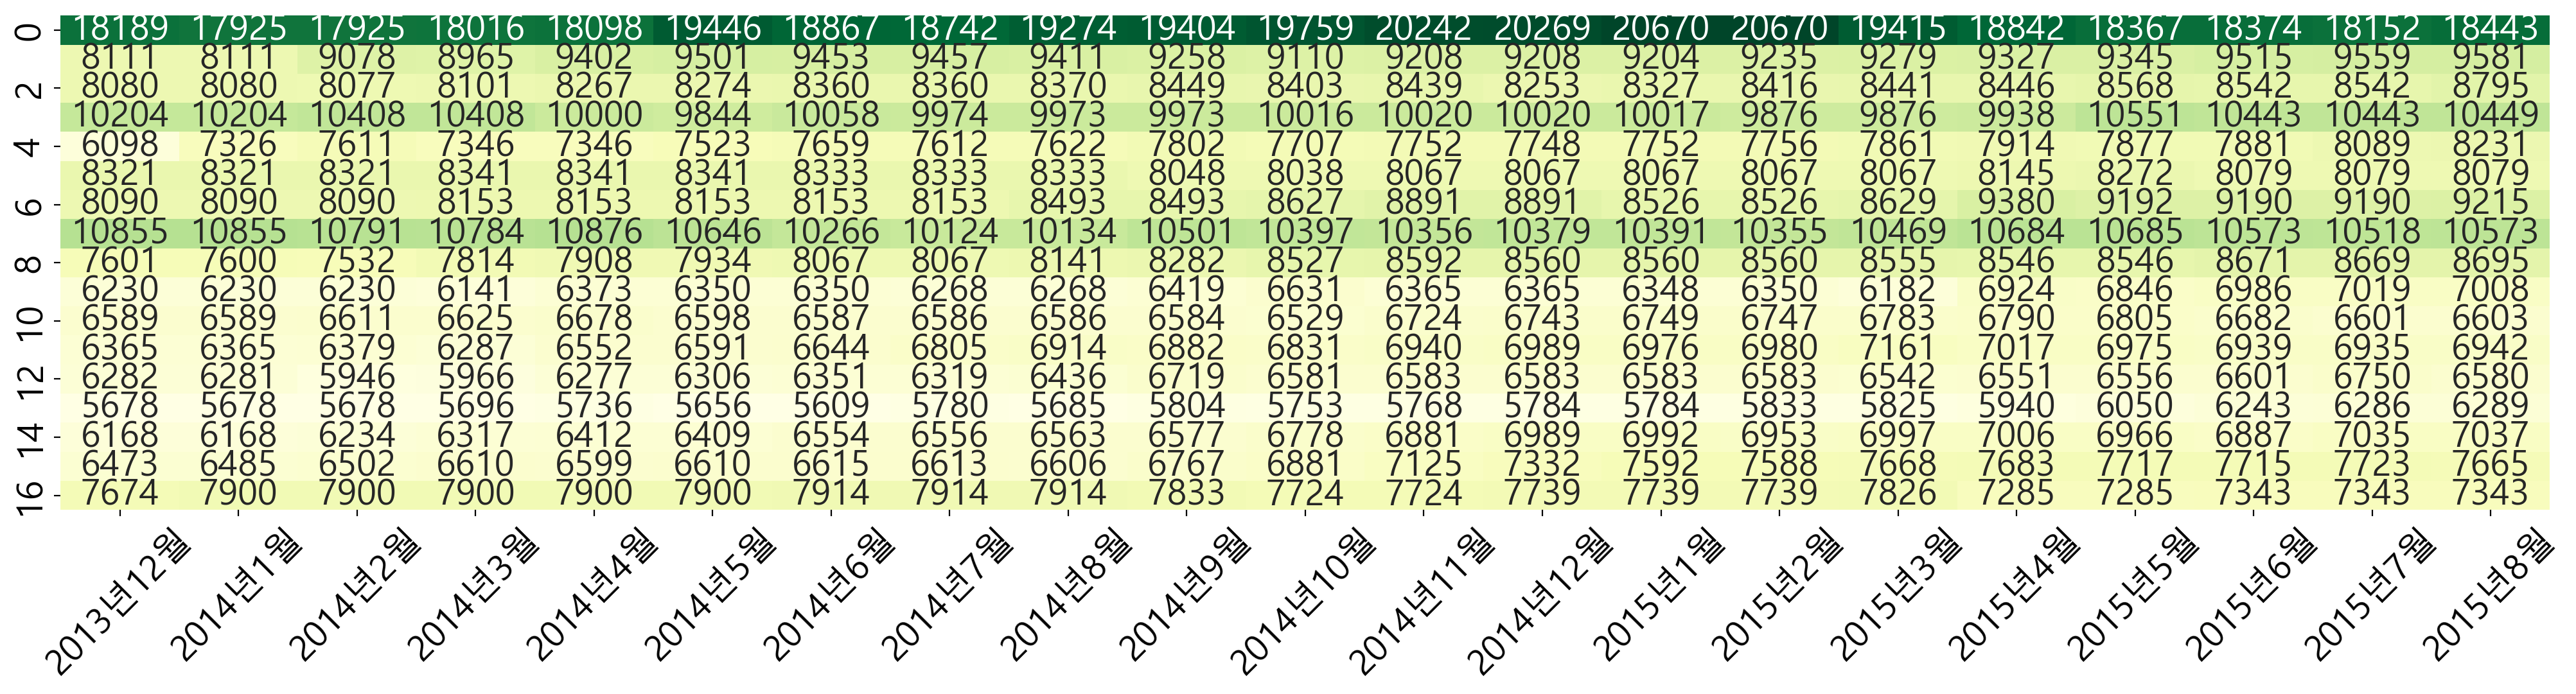

In [95]:
plt.figure(figsize=(25,5))
sns.heatmap(df_first.iloc[:, 1:], annot=True, fmt='d', cmap='YlGn', cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

## (2) 2015이후 데이터 분양가격에 간헐적으로 comma(,) 추가하여 csv로 출력

In [53]:
import numpy as np
df  = pd.read_csv(r'C:\ai\downloads\sharedata\분양가격\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')

for c in [col for col in df.columns if col.startswith("2015년")] :
    df[c] = df[c].map(
        lambda x: format(int(x),",") if np.random.rand() < 0.5 else x)

result = df.sample(n=5).sample(n=5, axis=1)
cols = [c for c in df.columns if c in result.columns]
result = result.sort_index()[cols] # 여기서 [cols] -> 열을 cols 리스트 순서대로 선택
result.to_csv(r'C:\ai\downloads\sharedata\분양가격\분양가격_랜덤5행5열.csv', index=False, encoding='cp949')
result

,2014년4월,2014년8월,2015년5월,2015년6월,2015년7월
2,8267,8370,8568,"8,542","8,542"
4,7346,7622,7877,7881,8089
11,6552,6914,6975,"6,939","6,935"
13,5736,5685,"6,050",6243,"6,286"
14,6412,6563,6966,"6,887",7035


In [ ]:
# isna(), isnull() - 결측치 여부
# notnull(), notna() - 결측치가 아닌지 여부


In [ ]:
# 분양가격(제곱미터당 천원)가 결측치인 행 상위2개


In [ ]:
# 분양가격(제곱미터당 천원) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()


In [ ]:
# 분양가격(제곱미터당 천원) 컬럼이 space인 행


In [ ]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    pass


In [ ]:
# 2020년전 데이터 흉내내기 위한 함수  : nan, ' ', '  ', '5123', '5,123'
def comma_append(row):
    pass

In [ ]:
# 간헐적으로 평당분양가에 ,가 있거나 np.nan이 있거나 space가 있는 데이터 csv로 백업

## (3) 이후 데이터는 df_last 변수에 담아 탐색

In [99]:
df_last = pd.read_csv(r'C:\ai\downloads\sharedata\분양가격\주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv', encoding='cp949')
df_last.shape

(10880, 5)

In [100]:
df_last.tail(3)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10879,제주,전용면적 102제곱미터초과,2026,5,4350


In [101]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [102]:
df_last['분양가격(제곱미터당 천원)'].describe()

count     10035
unique     3637
top            
freq         95
Name: 분양가격(제곱미터당 천원), dtype: object

# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [ ]:
# 열별 결측치 갯수


In [ ]:
# 열별 결측치를 제외한 갯수


# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정 후, 형변환
## (3) df_last['분양가격(제곱미터)']*3.3

### apply

In [ ]:
# 콤마가 있는 문자에서 콤마 없애기 방법
temp = '12,523'


In [ ]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    pass

commadrop(df_last.loc[0]) # 콤마 제외
commadrop(df_last.loc[1]) # 그대로
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
commadrop(df_last.loc[368]) # nan의 경우 nan

In [ ]:
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용


### map

In [ ]:
df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)
df_last.sample(1)

In [ ]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    pass

commadrop2(df_last.loc[0, '분양가격(제곱미터)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[1, '분양가격(제곱미터)']) # 콤마없는 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터)']) # nan을 nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [ ]:
#df_last['분양가격(제곱미터)'].apply(commadrop2)
#df_last['분양가격(제곱미터)'].map(commadrop2)

# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [ ]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

## (3) 전용면적별 평당분양가격(평균)

## (4) 지역별, 전용면적별 평당분양가격(평균)

## (5) 연도, 지역별 평당분양가격(평균)

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

## (2) 지역별 평당분양가격 (line, bar)

## (3) 전용면적별 평당분양가격(barplot)

## (4) 연도별 평균 평당분양가격(line)

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [ ]:
sns.set(style='white', rc={'figure.figsize':(9,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

## (2) 연도별 평당분양가격

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

## (2) 결측치 대체(연도별, 지역별 중위값)

## (3) df.csv파일로 출력

## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [ ]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ③ 연도별 평당분양가격(평균)

In [ ]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
